In [2081]:
#| echo: false
#| warning: false
#| output: asis

from IPython.display import Markdown, display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
from statsmodels.iolib.summary2 import summary_params
from scipy.stats import t, f, norm

# Не показывать Warning
import warnings
warnings.simplefilter(action='ignore', category=Warning)
# Не показывать ValueWarning, ConvergenceWarning из statsmodels
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning

# Загрузка данных
loanapp = pd.read_csv('../datasets/loanapp.csv')
mroz_Greene = pd.read_csv('../datasets/TableF5-1.csv')

# Настройки оформления графиков
plt.rcParams['figure.figsize'] = (8.5, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Подгонка модели

## approve equation #1

Для датасета `loanapp` рассмотрим регрессию __approve на mortno, unem, dep, male, married, yjob, self__

Спецификация:

$$
\begin{equation}
approve=\beta_0 + \beta_1 mortno+\beta_2 unem + \beta_3 dep + \beta_4 male + \beta_5 married + \beta_6 yjob + \beta_7 self + u
\end{equation}
$$

Альтернативная спецификация:

$$
\begin{equation}
P(approve=1)=\beta_0+\beta_1mortno+\beta_2unem+\beta_3dep+\beta_4male+\beta_5married+\beta_6yjob+\beta_7self
\end{equation}
$$

Оцените модель на данных и укажите коэффициенты подогнанной модели. __Ответ округлите до 3-х десятичных знаков.__

Ответ:

In [2082]:
#| echo: false
#| warning: false
#| output: asis

res = ols(formula = 'approve ~ mortno + unem + dep + male + married + yjob + self', data=loanapp).fit()
res_hc = ols(formula = 'approve ~ mortno + unem + dep + male + married + yjob + self', data=loanapp).fit(cov_type='HC3')

digits  = 3
# Формирование таблицы результатов
results_df = pd.DataFrame({
    'Переменная': res.params.index,
    'Оценка (OLS)': np.round(res.params, digits),
    #'Стд. ошибка (OLS)': np.round(res.bse, digits),
    'Оценка (HC3)': np.round(res_hc.params, digits),
    #'Стд. ошибка (HC3)': np.round(res_hc.bse, digits)
})

print(results_df.to_markdown(index=False))

| Переменная   |   Оценка (OLS) |   Оценка (HC3) |
|:-------------|---------------:|---------------:|
| Intercept    |          0.864 |          0.864 |
| mortno       |          0.073 |          0.073 |
| unem         |         -0.006 |         -0.006 |
| dep          |         -0.018 |         -0.018 |
| male         |          0.002 |          0.002 |
| married      |          0.046 |          0.046 |
| yjob         |         -0.001 |         -0.001 |
| self         |         -0.036 |         -0.036 |


__Дайте интерпретацию коэффициентам модели.__

## approve equation #2

Для датасета `loanapp` рассмотрим регрессию __approve на appinc, I(appinc ** 2), mortno, unem, dep, male, married, yjob, self__

Спецификация:

$$
\begin{equation}
approve=\beta_0 + \beta_1 appinc + \beta_2 appinc^{2} + \beta_3 mortno+\beta_4 unem + \beta_5 dep + \beta_6 male + \beta_7 married + \beta_8 yjob + \beta_9 self + u
\end{equation}
$$

Альтернативная спецификация:

$$
\begin{equation}
P(approve=1)=\beta_0 + \beta_1 appinc + \beta_2 appinc^{2} + \beta_3 mortno+\beta_4 unem + \beta_5 dep + \beta_6 male + \beta_7 married + \beta_8 yjob + \beta_9 self
\end{equation}
$$


Оцените модель на данных и укажите коэффициенты подогнанной модели. __Ответ округлите до 3-х десятичных знаков.__

Ответ:

In [2083]:
#| echo: false
#| warning: false
#| output: asis

res = ols(formula = 'approve ~ appinc + I(appinc ** 2) + mortno + unem + dep + male + married + yjob + self', data=loanapp).fit()
res_hc = ols(formula = 'approve ~ appinc + I(appinc ** 2) + mortno + unem + dep + male + married + yjob + self', data=loanapp).fit(cov_type='HC3')

digits  = 3
# Формирование таблицы результатов
results_df = pd.DataFrame({
    'Переменная': res.params.index,
    'Оценка (OLS)': np.round(res.params, digits),
    #'Стд. ошибка (OLS)': np.round(res.bse, digits),
    'Оценка (HC3)': np.round(res_hc.params, digits),
    #'Стд. ошибка (HC3)': np.round(res_hc.bse, digits)
})

print(results_df.to_markdown(index=False))

| Переменная     |   Оценка (OLS) |   Оценка (HC3) |
|:---------------|---------------:|---------------:|
| Intercept      |          0.842 |          0.842 |
| appinc         |          0.001 |          0.001 |
| I(appinc ** 2) |         -0     |         -0     |
| mortno         |          0.066 |          0.066 |
| unem           |         -0.006 |         -0.006 |
| dep            |         -0.017 |         -0.017 |
| male           |         -0.003 |         -0.003 |
| married        |          0.043 |          0.043 |
| yjob           |         -0.001 |         -0.001 |
| self           |         -0.04  |         -0.04  |


__Дайте интерпретацию коэффициентам модели.__

## labour force equation #1

Для датасета `TableF5-1` рассмотрим регрессию __LFP на WA, I(WA ** 2), WE, KL6, K618, CIT, UN, np.log(FAMINC)__

Спецификация:

$$
\begin{equation}
LFP=\beta_0+\beta_1WA+\beta_2WA^2+\beta_3WE+\beta_4KL6+\beta_5K618+\beta_6CIT+\beta_7UN+\beta_8\log(FAMINC)+u
\end{equation}
$$

Альтернативная спецификация:

$$
\begin{equation}
P(LFP=1)=\beta_0+\beta_1WA+\beta_2WA^2+\beta_3WE+\beta_4KL6+\beta_5K618+\beta_6CIT+\beta_7UN+\beta_8\log(FAMINC)
\end{equation}
$$

Оцените модель на данных и укажите коэффициенты подогнанной модели. __Ответ округлите до 3-х десятичных знаков.__

Ответ:

In [2084]:
#| echo: false
#| warning: false
#| output: asis

res = ols(formula = 'LFP ~ WA + I(WA ** 2) + WE + KL6 + K618 + CIT + UN + np.log(FAMINC)', data=mroz_Greene).fit()
res_hc = ols(formula = 'LFP ~ WA + I(WA ** 2) + WE + KL6 + K618 + CIT + UN + np.log(FAMINC)', data=mroz_Greene).fit(cov_type='HC3')

digits  = 3
# Формирование таблицы результатов
results_df = pd.DataFrame({
    'Переменная': res.params.index,
    'Оценка (OLS)': np.round(res.params, digits),
    #'Стд. ошибка (OLS)': np.round(res.bse, digits),
    'Оценка (HC3)': np.round(res_hc.params, digits),
    #'Стд. ошибка (HC3)': np.round(res_hc.bse, digits)
})

print(results_df.to_markdown(index=False))

| Переменная     |   Оценка (OLS) |   Оценка (HC3) |
|:---------------|---------------:|---------------:|
| Intercept      |         -0.321 |         -0.321 |
| WA             |          0.008 |          0.008 |
| I(WA ** 2)     |         -0     |         -0     |
| WE             |          0.038 |          0.038 |
| KL6            |         -0.296 |         -0.296 |
| K618           |         -0.021 |         -0.021 |
| CIT            |         -0.048 |         -0.048 |
| UN             |         -0.004 |         -0.004 |
| np.log(FAMINC) |          0.072 |          0.072 |


__Дайте интерпретацию коэффициентам модели.__

## labour force equation #2

Для датасета `TableF5-1` рассмотрим регрессию __LFP на WA, WE, CIT, UN, np.log(FAMINC)__

Спецификация:

$$
\begin{equation}
LFP = \beta_0 + \beta_1 WA + \beta_2 WE + \beta_3 CIT + \beta_4 CIT+\beta_5 UN + \beta_6 \log(FAMINC)+u
\end{equation}
$$

Альтернативная спецификация:

$$
\begin{equation}
P(LFP=1) = \beta_0 + \beta_1 WA + \beta_2 WE + \beta_3 CIT + \beta_4 CIT+\beta_5 UN + \beta_6 \log(FAMINC)
\end{equation}
$$

Оцените модель на данных и укажите коэффициенты подогнанной модели. __Ответ округлите до 3-х десятичных знаков.__

Ответ:

In [2085]:
#| echo: false
#| warning: false
#| output: asis

res = ols(formula = 'LFP ~ WA + WE + CIT + UN + np.log(FAMINC)', data=mroz_Greene).fit()
res_hc = ols(formula = 'LFP ~ WA + WE + CIT + UN + np.log(FAMINC)', data=mroz_Greene).fit(cov_type='HC3')

digits  = 3
# Формирование таблицы результатов
results_df = pd.DataFrame({
    'Переменная': res.params.index,
    'Оценка (OLS)': np.round(res.params, digits),
    #'Стд. ошибка (OLS)': np.round(res.bse, digits),
    'Оценка (HC3)': np.round(res_hc.params, digits),
    #'Стд. ошибка (HC3)': np.round(res_hc.bse, digits)
})

print(results_df.to_markdown(index=False))

| Переменная     |   Оценка (OLS) |   Оценка (HC3) |
|:---------------|---------------:|---------------:|
| Intercept      |         -0.536 |         -0.536 |
| WA             |         -0.004 |         -0.004 |
| WE             |          0.033 |          0.033 |
| CIT            |         -0.048 |         -0.048 |
| UN             |         -0.005 |         -0.005 |
| np.log(FAMINC) |          0.094 |          0.094 |


__Дайте интерпретацию коэффициентам модели.__

## Замечание: почему log(FAMINC)

Нарисуем гистограмму $\textrm{FAMINC}$ с наложенной кривой нормального распределения

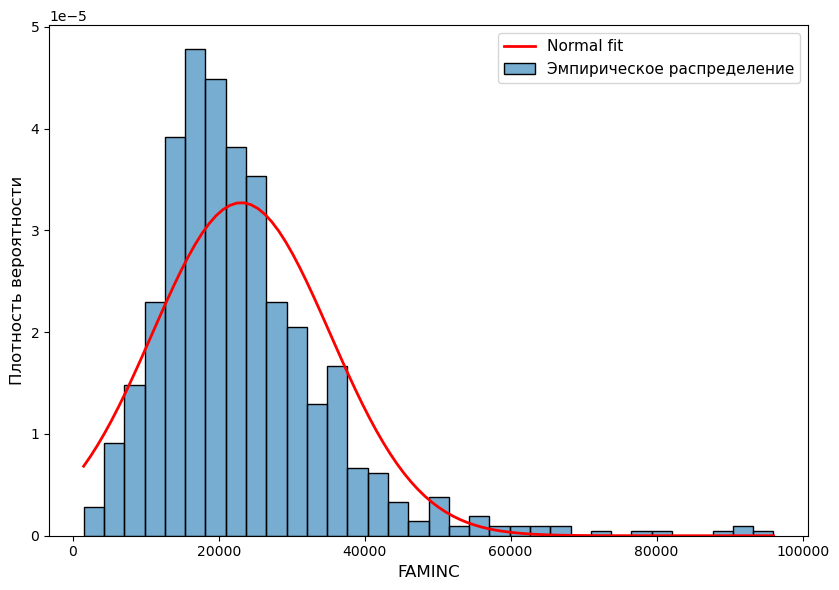

In [2086]:
#| echo: false
#| warning: false
#| label: fig-faminc-dist
#| fig-cap: "Гистограмма распределения дохода семьи ($\\textrm{FAMINC}$) с наложением нормальной кривой плотности."
#| fig-align: "center"

# Включаем красивый стиль seaborn (можно вынести в самую первую ячейку ноутбука)
#sns.set_theme(style="whitegrid", palette="muted")

FAMINC = mroz_Greene['FAMINC']

#plt.figure(figsize=(8, 5))

# Строим гистограмму с помощью seaborn
sns.histplot(
    FAMINC, 
    bins='fd', 
    stat='density', # Аналог density=True в matplotlib
    alpha=0.6, 
    edgecolor='black',
    label='Эмпирическое распределение'
)

# Наложение теоретического нормального распределения
x_vals = np.linspace(FAMINC.min(), FAMINC.max(), 100)
y_vals = norm.pdf(x_vals, FAMINC.mean(), FAMINC.std())
plt.plot(x_vals, y_vals, 'r-', linewidth=2, label='Normal fit')

#plt.title('Распределение дохода семьи (FAMINC)', fontsize=14)
plt.xlabel('FAMINC', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

Нарисуем гистограмму $\log(\textrm{FAMINC})$ с наложенной кривой нормального распределения

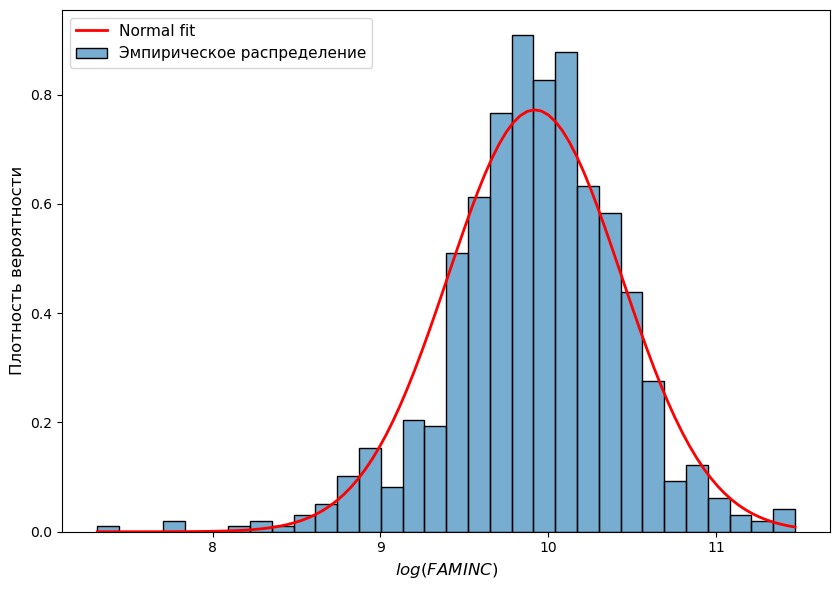

In [2087]:
#| echo: false
#| warning: false
#| label: fig-log-faminc
#| fig-cap: "Гистограмма логарифмированного дохода семьи с наложением нормальной кривой плотности."
#| fig-align: "center"

# Логарифмируем данные
log_FAMINC = np.log(mroz_Greene['FAMINC'])

#plt.figure(figsize=(8, 5))

# Гистограмма через seaborn
sns.histplot(
    log_FAMINC, 
    bins='fd', 
    stat='density', 
    alpha=0.6, 
    edgecolor='black',
    label='Эмпирическое распределение'
)

# Наложение теоретического нормального распределения
x_vals = np.linspace(log_FAMINC.min(), log_FAMINC.max(), 100)
y_vals = norm.pdf(x_vals, log_FAMINC.mean(), log_FAMINC.std())
plt.plot(x_vals, y_vals, 'r-', linewidth=2, label='Normal fit')

#plt.title('Распределение логарифма дохода семьи', fontsize=14)
plt.xlabel('$log(FAMINC)$', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# t-тест

## approve equation #1

Для датасета `loanapp` рассмотрим регрессию __approve на mortno, unem, dep, male, married, yjob, self__

Оцените модель на данных и укажите (робастные) коэффициенты подогнанной модели. __Ответ округлите до 3-х десятичных знаков.__

Ответ:

In [2088]:
#| echo: false
#| warning: false
#| output: asis

res = ols(formula = 'approve ~ 1 + mortno + unem + dep + male + married + yjob + self', data=loanapp).fit()
res_hc = ols(formula = 'approve ~ 1 + mortno + unem + dep + male + married + yjob + self', data=loanapp).fit(cov_type='HC3')

digits = 3
# Формирование таблицы результатов
results_df = pd.DataFrame({
    'Переменная': res.params.index,
    #'Оценка (OLS)': np.round(res.params, digits),
    #'Стд. ошибка (OLS)': np.round(res.bse, digits),
    'Оценка (HC3)': np.round(res_hc.params, digits),
    #'Стд. ошибка (HC3)': np.round(res_hc.bse, digits)
})

print(results_df.to_markdown(index=False))

| Переменная   |   Оценка (HC3) |
|:-------------|---------------:|
| Intercept    |          0.864 |
| mortno       |          0.073 |
| unem         |         -0.006 |
| dep          |         -0.018 |
| male         |          0.002 |
| married      |          0.046 |
| yjob         |         -0.001 |
| self         |         -0.036 |


In [2089]:
#| echo: false
#| warning: false
#| output: asis

# Уровень значимости
sign_level = 0.01

text = f"""
Модель была подогнана по {res.nobs:.0f} наблюдению. <span style="color: blue">Уровень значимости {sign_level * 100:.0f}%</span>
"""

display(Markdown(text))


Модель была подогнана по 1971 наблюдению. <span style="color: blue">Уровень значимости 1%</span>


Вычислите критическое значения для $t$-теста. __Ответ округлите до 3-х десятичных знаков.__

In [2090]:
#| echo: false
#| warning: false
#| output: asis

from IPython.display import display, Markdown
import scipy.stats as stats

def display_answer(text, use_callout=True, theme="tip", title="Критическое значение"):
    """
    Универсальная функция вывода текстовых блоков для Quarto.
    
    Параметры:
    - text: текст для вывода (строка).
    - use_callout: True оборачивает в рамку, False выводит как текст.
    - theme: цвет рамки ('tip' - зеленый, 'note' - синий, 'warning' - оранжевый).
    - title: текст заголовка. Если передать None или пустую строку, заголовок скроется.
    """
    
    if use_callout:
        # Формируем блок callout (обязательны пустые строки \n\n по краям)
        if title:
            # С заголовком
            output_md = f"\n\n::: {{.callout-{theme} title=\"{title}\" icon=\"true\"}}\n{text}\n:::\n\n"
        else:
            # Без заголовка (Quarto поддерживает скрытие заголовка, если его не указать)
            output_md = f"\n\n::: {{.callout-{theme} icon=\"true\"}}\n{text}\n:::\n\n"
            
    else:
        # Формируем обычный текст
        if title:
            output_md = f"\n\n**{title}:** {text}\n\n"
        else:
            output_md = f"\n\n{text}\n\n"

    # Печатаем результат
    display(Markdown(output_md))

# --- ВАШИ ВЫЧИСЛЕНИЯ ---

sign_level = 0.01
t_crit = stats.t.isf(q=sign_level/2, df=res.df_resid) 
answer_text = f"$t_{{crit}} = {t_crit:.3f}$" #f"$t_{{crit}} = {t_crit:.3f}$ на уровне значимости $\\alpha = {sign_level * 100:.0f}\%$."


# ================= ПРИМЕРЫ ВЫЗОВА =================

# 1. Зеленая рамка со стандартным заголовком "Ответ"
display_answer(answer_text)

# 2. Обычный текст (Без рамки, но с жирным "Ответ:")
# display_answer(answer_text, use_callout=False)

# 3. Синяя рамка (note) со своим заголовком
# display_answer(answer_text, theme="note", title="Критическое значение t-теста")

# 4. Обычный текст ВООБЩЕ БЕЗ заголовка (просто голый ответ)
# display_answer(answer_text, use_callout=False, title=None)

# 5. Рамка-предупреждение (оранжевая) без заголовка
# display_answer("Осторожно, гетероскедастичность!", theme="warning", title=None)



::: {.callout-tip title="Критическое значение" icon="true"}
$t_{crit} = 2.578$
:::



__Укажите результаты робастного и неробастного $t$-теста. Ответ округлите до 3-х десятичных знаков.__

In [2091]:
#| echo: false
#| warning: false
#| output: asis

from IPython.display import display, Markdown
from statsmodels.iolib.summary2 import summary_params

def print_regression_summary(res, sign_level=0.05, decimals=3, show_signif=True, show_text=True, use_callout=False, callout_title="Ответ"):
    """
    Форматирует и выводит компактную таблицу t-теста коэффициентов регрессии для Quarto.
    """
    # --- 0. ИСПРАВЛЕНИЕ ШИРИНЫ ТАБЛИЦЫ ДЛЯ HTML ---
    # Отключаем растягивание на 100% и центрируем таблицу. 
    # # При экспорте в PDF этот блок будет проигнорирован.
    # css_fix = "<style>table { width: auto !important; margin-left: auto; margin-right: auto; }</style>\n\n"

    # --- 1. АВТОМАТИЧЕСКИЙ ЗАГОЛОВОК И ТИП ОШИБОК ---
    cov_type = getattr(res, 'cov_type', 'nonrobust')
    
    if cov_type == 'nonrobust':
        title = "__Результаты $t$-теста для коэффициентов (неробастные стандартные ошибки, s.e.)__" #"### t test of coefficients (OLS Standard Errors)"
        error_text = "по классическим стандартным ошибкам"
    else:
        title = f"__Результаты $t$-теста для коэффициентов (робастные стандартные ошибки, {cov_type}-s.e.): __" #"### t test of coefficients (Robust Standard Errors: {cov_type})"
        error_text = f"по робастным стандартным ошибкам {cov_type}"

    # --- 2. ПОДГОТОВКА ТАБЛИЦЫ И ПЕРЕИМЕНОВАНИЕ СТОЛБЦОВ ---
    df_params = summary_params(res, alpha=sign_level).iloc[:, :-2]
    
    df_params = df_params.rename(columns={
        'P>|t|': 'p-value', 
        'P>|z|': 'p-value',
        't': 't-value',
        'z': 'z-value'
    })
    
    legend_text = ""
    
    # --- 3. КОДЫ ЗНАЧИМОСТИ ---
    if show_signif:
        def get_stars(p_value):
            if p_value < 0.01: return '***'
            elif p_value < 0.05: return '**'
            elif p_value < 0.1: return '*'
            return ''
            
        df_params['Signif.'] = df_params.iloc[:, 3].apply(get_stars)
        
        for const_name in ['const', 'Intercept']:
            if const_name in df_params.index:
                df_params.loc[const_name, 'Signif.'] = ''
                
        # Надежный формат: текст курсивом, а сами спецсимволы обернуты в код (обратные кавычки)
        legend_text = "\n*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$"
        
    # --- 4. ОКРУГЛЕНИЕ ---
    df_params = df_params.round(decimals)
    
    markdown_table = df_params.to_markdown(index=True)

    # --- 5. ТЕКСТОВЫЙ ВЫВОД ЗНАЧИМЫХ ФАКТОРОВ ---
    summary_text = ""
    if show_text:
        all_sign_coeffs = res.params.index[res.pvalues < sign_level].tolist()
        sign_coeffs = [coef for coef in all_sign_coeffs if coef not in ['const', 'Intercept']]
        percent_level = f"{sign_level * 100:g}"
        
        # Сначала формируем чистый текст
        if sign_coeffs:
            formatted_coeffs = ", ".join([f"`{coef}`" for coef in sign_coeffs])
            raw_text = f"**Коэффициенты, значимые на уровне {percent_level}% ({error_text}):** {formatted_coeffs}."
        else:
            raw_text = f"**На уровне значимости {percent_level}% ({error_text}) значимых коэффициентов не выявлено.**"

        # Если запрошен callout, оборачиваем только текст в блок .callout-tip
        if use_callout:
            # Для f-строк фигурные скобки у классов экранируются удвоением: {{.callout-tip}}
            summary_text = f"\n\n::: {{.callout-tip title=\"{callout_title}\" icon=\"true\"}}\n{raw_text}\n:::"
        else:
            summary_text = f"\n\n{raw_text}"

    # --- 6. ФИНАЛЬНАЯ СБОРКА И ВЫВОД ---
    # Таблица печатается как обычно, а summary_text подставляется уже в нужном формате (в рамке или без)
    final_output = f"{title}\n\n{markdown_table}\n{legend_text}{summary_text}"
    display(Markdown(final_output))

# Пример вызова
# Стандартный вызов (3 знака после запятой)
# print_regression_summary(res_hc)

# Округление до 4 знаков и уровень значимости 1%
# print_regression_summary(res_hc, sign_level=0.01, decimals=4)

# Вывод только таблицы с округлением до 2 знаков (без звездочек и текста)
# print_regression_summary(res_ols, decimals=2, show_signif=False, show_text=False)

In [2092]:
#| echo: false
#| warning: false
#| output: asis

# Вывод результатов t-теста с уровнем значимости sign_level, звездочками, без текста и без рамки
print_regression_summary(res, sign_level=sign_level, show_signif=True, show_text=False, use_callout=False)

__Результаты $t$-теста для коэффициентов (неробастные стандартные ошибки, s.e.)__

|           |   Coef. |   Std.Err. |   t-value |   p-value | Signif.   |
|:----------|--------:|-----------:|----------:|----------:|:----------|
| Intercept |   0.864 |      0.022 |    39.444 |     0     |           |
| mortno    |   0.073 |      0.016 |     4.578 |     0     | ***       |
| unem      |  -0.006 |      0.003 |    -1.858 |     0.063 | *         |
| dep       |  -0.018 |      0.007 |    -2.57  |     0.01  | **        |
| male      |   0.002 |      0.02  |     0.094 |     0.925 |           |
| married   |   0.046 |      0.018 |     2.604 |     0.009 | ***       |
| yjob      |  -0.001 |      0.007 |    -0.099 |     0.921 |           |
| self      |  -0.036 |      0.022 |    -1.621 |     0.105 |           |

*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$

Какие коэффициенты значимы?

In [2094]:
#| echo: false
#| warning: false
#| output: asis

from IPython.display import display, Markdown

def print_significant_coeffs(res, sign_level=0.05, use_callout=False, theme="tip", title=None):
    """
    Выводит список статистически значимых коэффициентов регрессии (без константы).
    """
    # 1. Автоматически извлекаем тип стандартных ошибок из модели
    cov_type = getattr(res, 'cov_type', 'nonrobust')
    is_robust = cov_type != 'nonrobust'
    
    if is_robust:
        error_type = f"по робастным стандартным ошибкам {cov_type}"
    else:
        error_type = "по классическим стандартным ошибкам"

    # 2. Отбираем значимые коэффициенты
    all_sign_coeffs = res.params.index[res.pvalues < sign_level].tolist()

    # 3. Исключаем константу
    sign_coeffs = [coef for coef in all_sign_coeffs if coef not in ['const', 'Intercept']]

    # 4. Переводим уровень значимости в проценты
    percent_level = f"{sign_level * 100:g}"

    # --- 5. ФОРМИРУЕМ ЭЛЕМЕНТЫ ВЫВОДА ---
    
    # Базовый динамический заголовок
    dynamic_title = f"Коэффициенты, значимые на уровне {percent_level}% ({error_type})"
    
    # Заголовок, который реально будет использован (динамический, если не передан свой)
    actual_title = title if title is not None else dynamic_title

    # Содержимое (только переменные или короткое сообщение об отсутствии)
    if sign_coeffs:
        formatted_coeffs = ", ".join([f"`{coef}`" for coef in sign_coeffs])
        content_text = formatted_coeffs
    else:
        content_text = "Значимых коэффициентов не выявлено."

    # --- 6. СОБИРАЕМ РЕЗУЛЬТАТ С РАМКОЙ ИЛИ БЕЗ ---
    
    if use_callout:
        # В рамке: подробный текст уходит в заголовок, внутри только список переменных
        output_md = f"\n\n::: {{.callout-{theme} title=\"{actual_title}\" icon=\"true\"}}\n{content_text}\n:::\n\n"
    else:
        # Без рамки: все в одной строке (с жирным префиксом)
        output_md = f"\n\n**{actual_title}:**\n\n {content_text}\n\n"

    display(Markdown(output_md))

In [2095]:
# Выводим значимые коэффициенты для модели с неробастными стандартными ошибками на уровне sign_level, в рамке
print_significant_coeffs(res, sign_level=sign_level, use_callout=True)



::: {.callout-tip title="Коэффициенты, значимые на уровне 1% (по классическим стандартным ошибкам)" icon="true"}
`mortno`, `married`
:::



In [2093]:
#| echo: false
#| warning: false
#| output: asis

# Вывод результатов t-теста с уровнем значимости sign_level, звездочками, без текста и без рамки
print_regression_summary(res_hc, sign_level=0.01, show_signif=True, show_text=False, use_callout=False)

__Результаты $t$-теста для коэффициентов (робастные стандартные ошибки, HC3-s.e.): __

|           |   Coef. |   Std.Err. |   t-value |   p-value | Signif.   |
|:----------|--------:|-----------:|----------:|----------:|:----------|
| Intercept |   0.864 |      0.023 |    37.135 |     0     |           |
| mortno    |   0.073 |      0.015 |     4.886 |     0     | ***       |
| unem      |  -0.006 |      0.004 |    -1.605 |     0.108 |           |
| dep       |  -0.018 |      0.008 |    -2.429 |     0.015 | **        |
| male      |   0.002 |      0.021 |     0.089 |     0.929 |           |
| married   |   0.046 |      0.019 |     2.458 |     0.014 | **        |
| yjob      |  -0.001 |      0.006 |    -0.107 |     0.915 |           |
| self      |  -0.036 |      0.025 |    -1.464 |     0.143 |           |

*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$

Какие коэффициенты значимы?

In [2096]:
# Выводим значимые коэффициенты для модели с робастными стандартными ошибками HC3 на уровне sign_level, в рамке
print_significant_coeffs(res_hc, sign_level=sign_level, use_callout=True)



::: {.callout-tip title="Коэффициенты, значимые на уровне 1% (по робастным стандартным ошибкам HC3)" icon="true"}
`mortno`
:::




::: {.callout-note}
## Расшифровка кодов статистической значимости (Signif. codes)

В таблицах регрессионного анализа звездочками традиционно обозначается $p$-значение (p-value) для каждого коэффициента. Чем меньше $p$-значение, тем сильнее статистические доказательства против нулевой гипотезы ($H_0$), согласно которой данный фактор не влияет на зависимую переменную (истинный коэффициент равен нулю).

* `***` : **$p < 0.01$** (от 0 до 0.01) — *высокая значимость*. Нулевая гипотеза отвергается на уровне значимости 1%.
* `**` : **$0.01 \le p < 0.05$** — *стандартная значимость*. Коэффициент значим на 5% уровне. Это самый распространенный порог для подтверждения гипотез в большинстве исследований.
* `*` : **$0.05 \le p < 0.1$** — *маргинальная (слабая) значимость*. Коэффициент значим лишь на 10% уровне. В строгих моделях предиктор признают незначимым, но иногда интерпретируют как «статистическую тенденцию».
* ` ` (пустое место) : **$p \ge 0.1$** (от 0.1 до 1) — *статистически не значимо*. У нас нет достаточных оснований утверждать, что переменная оказывает влияние на результат.
:::

## approve equation #2

Для датасета `loanapp` рассмотрим регрессию __approve на appinc, I(appinc ** 2), mortno, unem, dep, male, married, yjob, self__

Оцените модель на данных и укажите (робастные) коэффициенты подогнанной модели. __Ответ округлите до 3-х десятичных знаков.__

Ответ:

In [2097]:
#| echo: false
#| warning: false
#| output: asis

res = ols(formula = 'approve ~ 1 + appinc + I(appinc ** 2) + mortno + unem + dep + male + married + yjob + self', data=loanapp).fit()
res_hc = ols(formula = 'approve ~ 1 + appinc + I(appinc ** 2) + mortno + unem + dep + male + married + yjob + self', data=loanapp).fit(cov_type='HC3')

digits = 3
# Формирование таблицы результатов
results_df = pd.DataFrame({
    'Переменная': res.params.index,
    #'Оценка (OLS)': np.round(res.params, digits),
    #'Стд. ошибка (OLS)': np.round(res.bse, digits),
    'Оценка (HC3)': np.round(res_hc.params, digits),
    #'Стд. ошибка (HC3)': np.round(res_hc.bse, digits)
})

print(results_df.to_markdown(index=False))

| Переменная     |   Оценка (HC3) |
|:---------------|---------------:|
| Intercept      |          0.842 |
| appinc         |          0.001 |
| I(appinc ** 2) |         -0     |
| mortno         |          0.066 |
| unem           |         -0.006 |
| dep            |         -0.017 |
| male           |         -0.003 |
| married        |          0.043 |
| yjob           |         -0.001 |
| self           |         -0.04  |


In [2098]:
#| echo: false
#| warning: false
#| output: asis

# Уровень значимости
sign_level = 0.01

text = f"""
Модель была подогнана по {res.nobs:.0f} наблюдению. <span style="color: blue">Уровень значимости {sign_level * 100:.0f}%</span>
"""

display(Markdown(text))


Модель была подогнана по 1971 наблюдению. <span style="color: blue">Уровень значимости 1%</span>


Вычислите критическое значения для $t$-теста. __Ответ округлите до 3-х десятичных знаков.__

Ответ:

In [2099]:
#| echo: false
#| warning: false
#| output: asis

# Уровень значимости
sign_level = 0.01
# Критическое значение t-распределения для двустороннего теста (делим уровень на 2) и соответствующих степеней свободы
t_crit = stats.t.isf(q=sign_level/2, df=res.df_resid)

# Формируем текст ответа с динамическим подставлением критического значения и уровня значимости
answer_text = f"$t_{{crit}} = {t_crit:.3f}$"

# Вывод критического значения в рамке с заголовком "Критическое значение"
display_answer(answer_text)



::: {.callout-tip title="Критическое значение" icon="true"}
$t_{crit} = 2.578$
:::



__Укажите результаты робастного и неробастного $t$-теста. Ответ округлите до 3-х десятичных знаков.__

In [2100]:
#| echo: false
#| warning: false
#| output: asis

# Вывод результатов t-теста с уровнем значимости sign_level, звездочками, без текста и без рамки
print_regression_summary(res, sign_level=sign_level, show_signif=True, show_text=False, use_callout=False)

__Результаты $t$-теста для коэффициентов (неробастные стандартные ошибки, s.e.)__

|                |   Coef. |   Std.Err. |   t-value |   p-value | Signif.   |
|:---------------|--------:|-----------:|----------:|----------:|:----------|
| Intercept      |   0.842 |      0.025 |    33.3   |     0     |           |
| appinc         |   0.001 |      0     |     2.082 |     0.037 | **        |
| I(appinc ** 2) |  -0     |      0     |    -2.803 |     0.005 | ***       |
| mortno         |   0.066 |      0.016 |     4.029 |     0     | ***       |
| unem           |  -0.006 |      0.003 |    -1.757 |     0.079 | *         |
| dep            |  -0.017 |      0.007 |    -2.374 |     0.018 | **        |
| male           |  -0.003 |      0.02  |    -0.142 |     0.887 |           |
| married        |   0.043 |      0.018 |     2.449 |     0.014 | **        |
| yjob           |  -0.001 |      0.007 |    -0.132 |     0.895 |           |
| self           |  -0.04  |      0.023 |    -1.786 |     0.074 | *         |

*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$

Какие коэффициенты значимы?

In [2101]:
#| echo: false
#| warning: false
#| output: asis

# Выводим значимые коэффициенты для модели с неробастными стандартными ошибками на уровне sign_level, в рамке
print_significant_coeffs(res, sign_level=sign_level, use_callout=True)



::: {.callout-tip title="Коэффициенты, значимые на уровне 1% (по классическим стандартным ошибкам)" icon="true"}
`I(appinc ** 2)`, `mortno`
:::



In [2102]:
#| echo: false
#| warning: false
#| output: asis

# Вывод результатов t-теста с уровнем значимости sign_level, звездочками, без текста и без рамки
print_regression_summary(res_hc, sign_level=sign_level, show_signif=True, show_text=False, use_callout=False)

__Результаты $t$-теста для коэффициентов (робастные стандартные ошибки, HC3-s.e.): __

|                |   Coef. |   Std.Err. |   t-value |   p-value | Signif.   |
|:---------------|--------:|-----------:|----------:|----------:|:----------|
| Intercept      |   0.842 |      0.027 |    31.003 |     0     |           |
| appinc         |   0.001 |      0     |     1.958 |     0.05  | *         |
| I(appinc ** 2) |  -0     |      0     |    -2.374 |     0.018 | **        |
| mortno         |   0.066 |      0.015 |     4.321 |     0     | ***       |
| unem           |  -0.006 |      0.004 |    -1.515 |     0.13  |           |
| dep            |  -0.017 |      0.007 |    -2.28  |     0.023 | **        |
| male           |  -0.003 |      0.021 |    -0.135 |     0.893 |           |
| married        |   0.043 |      0.019 |     2.309 |     0.021 | **        |
| yjob           |  -0.001 |      0.006 |    -0.14  |     0.889 |           |
| self           |  -0.04  |      0.025 |    -1.602 |     0.109 |           |

*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$

Какие коэффициенты значимы?

In [2103]:
#| echo: false
#| warning: false
#| output: asis

# Выводим значимые коэффициенты для модели с робастными стандартными ошибками на уровне sign_level, в рамке
print_significant_coeffs(res_hc, sign_level=sign_level, use_callout=True)



::: {.callout-tip title="Коэффициенты, значимые на уровне 1% (по робастным стандартным ошибкам HC3)" icon="true"}
`mortno`
:::



## labour force equation #1

Для датасета `TableF5-1` рассмотрим регрессию __LFP на WA, I(WA ** 2), WE, KL6, K618, CIT, UN, np.log(FAMINC)__

Оцените модель на данных и укажите (робастные) коэффициенты подогнанной модели. __Ответ округлите до 3-х десятичных знаков.__

Ответ:

In [2104]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.01
res = ols(formula = 'LFP ~ 1 + WA + I(WA ** 2) + WE + KL6 + K618 + CIT + UN + np.log(FAMINC)', data=mroz_Greene).fit()
res_hc = ols(formula = 'LFP ~ 1 + WA + I(WA ** 2) + WE + KL6 + K618 + CIT + UN + np.log(FAMINC)', data=mroz_Greene).fit(cov_type='HC3')

digits = 3
# Формирование таблицы результатов
results_df = pd.DataFrame({
    'Переменная': res.params.index,
    #'Оценка (OLS)': np.round(res.params, digits),
    #'Стд. ошибка (OLS)': np.round(res.bse, digits),
    'Оценка (HC3)': np.round(res_hc.params, digits),
    #'Стд. ошибка (HC3)': np.round(res_hc.bse, digits)
})

print(results_df.to_markdown(index=False))

| Переменная     |   Оценка (HC3) |
|:---------------|---------------:|
| Intercept      |         -0.321 |
| WA             |          0.008 |
| I(WA ** 2)     |         -0     |
| WE             |          0.038 |
| KL6            |         -0.296 |
| K618           |         -0.021 |
| CIT            |         -0.048 |
| UN             |         -0.004 |
| np.log(FAMINC) |          0.072 |


In [2105]:
#| echo: false
#| warning: false
#| output: asis

# Уровень значимости
sign_level = 0.01

text = f"""
Модель была подогнана по {res.nobs:.0f} наблюдению. <span style="color: blue">Уровень значимости {sign_level * 100:.0f}%</span>
"""

display(Markdown(text))


Модель была подогнана по 753 наблюдению. <span style="color: blue">Уровень значимости 1%</span>


Вычислите критическое значения для $t$-теста. __Ответ округлите до 3-х десятичных знаков.__

Ответ:

In [2106]:
#| echo: false
#| warning: false
#| output: asis

# Уровень значимости
sign_level = 0.01
# Критическое значение t-распределения для двустороннего теста (делим уровень на 2) и соответствующих степеней свободы
t_crit = stats.t.isf(q=sign_level/2, df=res.df_resid)

# Формируем текст ответа с динамическим подставлением критического значения и уровня значимости
answer_text = f"$t_{{crit}} = {t_crit:.3f}$"

# Вывод критического значения в рамке с заголовком "Критическое значение"
display_answer(answer_text)



::: {.callout-tip title="Критическое значение" icon="true"}
$t_{crit} = 2.582$
:::



__Укажите результаты робастного и неробастного $t$-теста. Ответ округлите до 3-х десятичных знаков.__

In [2107]:
#| echo: false
#| warning: false
#| output: asis

# Вывод результатов t-теста с уровнем значимости sign_level, звездочками, без текста и без рамки
print_regression_summary(res, sign_level=sign_level, show_signif=True, show_text=False)

__Результаты $t$-теста для коэффициентов (неробастные стандартные ошибки, s.e.)__

|                |   Coef. |   Std.Err. |   t-value |   p-value | Signif.   |
|:---------------|--------:|-----------:|----------:|----------:|:----------|
| Intercept      |  -0.321 |      0.592 |    -0.542 |     0.588 |           |
| WA             |   0.008 |      0.025 |     0.305 |     0.76  |           |
| I(WA ** 2)     |  -0     |      0     |    -0.847 |     0.398 |           |
| WE             |   0.038 |      0.008 |     4.574 |     0     | ***       |
| KL6            |  -0.296 |      0.037 |    -8.011 |     0     | ***       |
| K618           |  -0.021 |      0.015 |    -1.434 |     0.152 |           |
| CIT            |  -0.048 |      0.038 |    -1.283 |     0.2   |           |
| UN             |  -0.004 |      0.006 |    -0.647 |     0.518 |           |
| np.log(FAMINC) |   0.072 |      0.037 |     1.965 |     0.05  | **        |

*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$

Какие коэффициенты значимы?

In [2108]:
#| echo: false
#| warning: false
#| output: asis

# Выводим значимые коэффициенты для модели с неробастными стандартными ошибками на уровне sign_level, в рамке
print_significant_coeffs(res, sign_level=sign_level, use_callout=True)



::: {.callout-tip title="Коэффициенты, значимые на уровне 1% (по классическим стандартным ошибкам)" icon="true"}
`WE`, `KL6`
:::



In [2109]:
#| echo: false
#| warning: false
#| output: asis

# Вывод результатов t-теста с уровнем значимости sign_level, звездочками, без текста и без рамки
print_regression_summary(res_hc, sign_level=sign_level, show_signif=True, show_text=False)

__Результаты $t$-теста для коэффициентов (робастные стандартные ошибки, HC3-s.e.): __

|                |   Coef. |   Std.Err. |   t-value |   p-value | Signif.   |
|:---------------|--------:|-----------:|----------:|----------:|:----------|
| Intercept      |  -0.321 |      0.585 |    -0.549 |     0.583 |           |
| WA             |   0.008 |      0.024 |     0.307 |     0.759 |           |
| I(WA ** 2)     |  -0     |      0     |    -0.843 |     0.399 |           |
| WE             |   0.038 |      0.008 |     4.736 |     0     | ***       |
| KL6            |  -0.296 |      0.034 |    -8.763 |     0     | ***       |
| K618           |  -0.021 |      0.015 |    -1.409 |     0.159 |           |
| CIT            |  -0.048 |      0.037 |    -1.3   |     0.193 |           |
| UN             |  -0.004 |      0.006 |    -0.633 |     0.527 |           |
| np.log(FAMINC) |   0.072 |      0.038 |     1.921 |     0.055 | *         |

*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$

Какие коэффициенты значимы?

In [2110]:
#| echo: false
#| warning: false
#| output: asis

# Выводим значимые коэффициенты для модели с робастными стандартными ошибками на уровне sign_level, в рамке
print_significant_coeffs(res_hc, sign_level=sign_level, use_callout=True)



::: {.callout-tip title="Коэффициенты, значимые на уровне 1% (по робастным стандартным ошибкам HC3)" icon="true"}
`WE`, `KL6`
:::



## labour force equation #2

Для датасета `TableF5-1` рассмотрим регрессию __LFP на WA, WE, CIT, UN, np.log(FAMINC)__

Оцените модель на данных и укажите (робастные) коэффициенты подогнанной модели. __Ответ округлите до 3-х десятичных знаков.__

Ответ:

In [2111]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.05
res = ols(formula = 'LFP ~ 1 + WA + WE + CIT + UN + np.log(FAMINC)', data=mroz_Greene).fit()
res_hc = ols(formula = 'LFP ~ 1 + WA + WE + CIT + UN + np.log(FAMINC)', data=mroz_Greene).fit(cov_type='HC3')

digits = 3
# Формирование таблицы результатов
results_df = pd.DataFrame({
    'Переменная': res.params.index,
    #'Оценка (OLS)': np.round(res.params, digits),
    #'Стд. ошибка (OLS)': np.round(res.bse, digits),
    'Оценка (HC3)': np.round(res_hc.params, digits),
    #'Стд. ошибка (HC3)': np.round(res_hc.bse, digits)
})

print(results_df.to_markdown(index=False))

| Переменная     |   Оценка (HC3) |
|:---------------|---------------:|
| Intercept      |         -0.536 |
| WA             |         -0.004 |
| WE             |          0.033 |
| CIT            |         -0.048 |
| UN             |         -0.005 |
| np.log(FAMINC) |          0.094 |


In [2112]:
#| echo: false
#| warning: false
#| output: asis

# Уровень значимости
sign_level = 0.05

text = f"""
Модель была подогнана по {res.nobs:.0f} наблюдению. <span style="color: blue">Уровень значимости {sign_level * 100:.0f}%</span>
"""

display(Markdown(text))


Модель была подогнана по 753 наблюдению. <span style="color: blue">Уровень значимости 5%</span>


Вычислите критическое значения для $t$-теста. __Ответ округлите до 3-х десятичных знаков.__

In [2113]:
#| echo: false
#| warning: false
#| output: asis

# Уровень значимости
sign_level = 0.05
# Критическое значение t-распределения для двустороннего теста (делим уровень на 2) и соответствующих степеней свободы
t_crit = stats.t.isf(q=sign_level/2, df=res.df_resid)

# Формируем текст ответа с динамическим подставлением критического значения и уровня значимости
answer_text = f"$t_{{crit}} = {t_crit:.3f}$"

# Вывод критического значения в рамке с заголовком "Критическое значение"
display_answer(answer_text)



::: {.callout-tip title="Критическое значение" icon="true"}
$t_{crit} = 1.963$
:::



__Укажите результаты робастного и неробастного $t$-теста. Ответ округлите до 3-х десятичных знаков.__

In [2114]:
#| echo: false
#| warning: false
#| output: asis

# Вывод результатов t-теста с уровнем значимости sign_level, звездочками, без текста и без рамки
print_regression_summary(res, sign_level=sign_level, show_signif=True, show_text=False, use_callout=False)

__Результаты $t$-теста для коэффициентов (неробастные стандартные ошибки, s.e.)__

|                |   Coef. |   Std.Err. |   t-value |   p-value | Signif.   |
|:---------------|--------:|-----------:|----------:|----------:|:----------|
| Intercept      |  -0.536 |      0.36  |    -1.488 |     0.137 |           |
| WA             |  -0.004 |      0.002 |    -1.668 |     0.096 | *         |
| WE             |   0.033 |      0.009 |     3.914 |     0     | ***       |
| CIT            |  -0.048 |      0.039 |    -1.217 |     0.224 |           |
| UN             |  -0.005 |      0.006 |    -0.868 |     0.386 |           |
| np.log(FAMINC) |   0.094 |      0.038 |     2.449 |     0.015 | **        |

*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$

Какие коэффициенты значимы?

In [2115]:
#| echo: false
#| warning: false
#| output: asis

# Выводим значимые коэффициенты для модели с неробастными стандартными ошибками на уровне sign_level, в рамке
print_significant_coeffs(res, sign_level=sign_level, use_callout=True)



::: {.callout-tip title="Коэффициенты, значимые на уровне 5% (по классическим стандартным ошибкам)" icon="true"}
`WE`, `np.log(FAMINC)`
:::



In [2116]:
#| echo: false
#| warning: false
#| output: asis

# Вывод результатов t-теста с уровнем значимости sign_level, звездочками, без текста и без рамки
print_regression_summary(res_hc, sign_level=sign_level, show_signif=True, show_text=False, use_callout=False)

__Результаты $t$-теста для коэффициентов (робастные стандартные ошибки, HC3-s.e.): __

|                |   Coef. |   Std.Err. |   t-value |   p-value | Signif.   |
|:---------------|--------:|-----------:|----------:|----------:|:----------|
| Intercept      |  -0.536 |      0.368 |    -1.457 |     0.145 |           |
| WA             |  -0.004 |      0.002 |    -1.635 |     0.102 |           |
| WE             |   0.033 |      0.008 |     4.036 |     0     | ***       |
| CIT            |  -0.048 |      0.039 |    -1.212 |     0.226 |           |
| UN             |  -0.005 |      0.006 |    -0.855 |     0.392 |           |
| np.log(FAMINC) |   0.094 |      0.04  |     2.351 |     0.019 | **        |

*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$

Какие коэффициенты значимы?

In [2117]:
#| echo: false
#| warning: false
#| output: asis

# Выводим значимые коэффициенты для модели с робастными стандартными ошибками на уровне sign_level, в рамке
print_significant_coeffs(res_hc, sign_level=sign_level, use_callout=True)



::: {.callout-tip title="Коэффициенты, значимые на уровне 5% (по робастным стандартным ошибкам HC3)" icon="true"}
`WE`, `np.log(FAMINC)`
:::



# F-тест: значимость регрессии

## approve equation #1

Для датасета `loanapp` рассмотрим регрессию __approve на unem, male, yjob, self__

Результаты оценивания:

In [2118]:
#| echo: false
#| warning: false
#| output: asis

digits = 3
sign_level = 0.10
res = ols(formula = 'approve ~ 1 + unem + male + yjob + self', data=loanapp).fit()
res_hc = ols(formula = 'approve ~ 1 + unem + male + yjob + self', data=loanapp).fit(cov_type='HC3')

# F-тест на значимость всей регрессии
print(f"- **F-stat (OLS):** {res.fvalue:.3f}, p-value: {res.f_pvalue:.3f}")
print(f"- **F-stat (Robust HC3):** {res_hc.fvalue:.3f}, p-value: {res_hc.f_pvalue:.3f}")

# Критическое значение F-распределения
F_crit = f.ppf(1 - sign_level, res.df_model, res.df_resid)

print(f"- **F_{{crit}}** (α={sign_level}) = {F_crit:.3f}\n")

if res_hc.f_pvalue < sign_level:
    print("**Вывод:** Регрессия **значима** на уровне α=0.10\n")
else:
    print("**Вывод:** Регрессия **незначима** на уровне α=0.10\n")

- **F-stat (OLS):** 2.029, p-value: 0.088
- **F-stat (Robust HC3):** 1.677, p-value: 0.153
- **F_{crit}** (α=0.1) = 1.948

**Вывод:** Регрессия **незначима** на уровне α=0.10



Тестируется значимость регрессии, т.е. гипотеза $H_0:\beta_{unem}=\beta_{male}=\beta_{yjob}=\beta_{self}=0$.

## approve equation #2

Для датасета `loanapp` рассмотрим регрессию __approve на appinc, I(appinc ** 2), mortno, dep__

In [2119]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.05
res = ols(formula = 'approve ~ appinc + I(appinc ** 2) + mortno + dep', data=loanapp).fit()
res_hc = ols(formula = 'approve ~ appinc + I(appinc ** 2) + mortno + dep', data=loanapp).fit(cov_type='HC3')

print(f"- **F-stat (OLS):** {res.fvalue:.3f}, p-value: {res.f_pvalue:.3f}")
print(f"- **F-stat (Robust HC3):** {res_hc.fvalue:.3f}, p-value: {res_hc.f_pvalue:.3f}")

F_crit = f.ppf(1 - sign_level, res.df_model, res.df_resid)
print(f"- **F_{{crit}}** (α={sign_level}) = {F_crit:.3f}\n")

if res_hc.f_pvalue < sign_level:
    print("**Вывод:** Регрессия **значима** на уровне α=0.05\n")
else:
    print("**Вывод:** Регрессия **незначима** на уровне α=0.05\n")

- **F-stat (OLS):** 9.106, p-value: 0.000
- **F-stat (Robust HC3):** 8.188, p-value: 0.000
- **F_{crit}** (α=0.05) = 2.376

**Вывод:** Регрессия **значима** на уровне α=0.05



Тестируется значимость регрессии, т.е. гипотеза $H_0:\beta_{appinc}=\beta_{appinc^2}=\beta_{mortno}=\beta_{dep}=0$.

## approve equation #3

Для датасета `loanapp` рассмотрим регрессию __approve на dep, male, married__

In [2120]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.01
res = ols(formula = 'approve ~ 1 + dep + male + married', data=loanapp).fit()
res_hc = ols(formula = 'approve ~ 1 + dep + male + married', data=loanapp).fit(cov_type='HC3')

print(f"- **F-stat (OLS):** {res.fvalue:.3f}, p-value: {res.f_pvalue:.3f}")
print(f"- **F-stat (Robust HC3):** {res_hc.fvalue:.3f}, p-value: {res_hc.f_pvalue:.3f}")

F_crit = f.ppf(1 - sign_level, res.df_model, res.df_resid)
print(f"- **F_{{crit}}** (α={sign_level}) = {F_crit:.3f}\n")

if res_hc.f_pvalue < sign_level:
    print("**Вывод:** Регрессия **значима** на уровне α=0.01\n")
else:
    print("**Вывод:** Регрессия **незначима** на уровне α=0.01\n")

- **F-stat (OLS):** 4.155, p-value: 0.006
- **F-stat (Robust HC3):** 3.724, p-value: 0.011
- **F_{crit}** (α=0.01) = 3.792

**Вывод:** Регрессия **незначима** на уровне α=0.01



Тестируется значимость регрессии, т.е. гипотеза $H_0:\beta_{dep}=\beta_{male}=\beta_{married}=0$.

# F-тест: совместная значимость

## approve equation #1

Для датасета `loanapp` рассмотрим регрессию __approve на appinc, I(appinc ** 2), mortno, unem, dep, male, married, yjob, self__

In [2121]:
#| echo: false
#| warning: false
#| output: asis

res = ols(formula = 'approve ~ 1 + appinc + I(appinc ** 2) + mortno + unem + dep + male + married + yjob + self', data=loanapp).fit()
res_hc = ols(formula = 'approve ~ 1 + appinc + I(appinc ** 2) + mortno + unem + dep + male + married + yjob + self', data=loanapp).fit(cov_type='HC3')

### Гипотеза 1: значимость влияния дохода
sign_level = 0.05
hypothesis = ['appinc', 'I(appinc ** 2)']
F_result = res.f_test(hypothesis)
F_robust_result = res_hc.f_test(hypothesis)

print("### Гипотеза H₀: $\\beta_{appinc} = \\beta_{appinc^2} = 0$ (α=0.05)\n")
print(f"- **F-stat (OLS):** {F_result.statistic:.3f}, p-value: {F_result.pvalue:.3f}")
print(f"- **F-stat (Robust HC3):** {F_robust_result.statistic:.3f}, p-value: {F_robust_result.pvalue:.3f}")

F_crit = f.ppf(1 - sign_level, len(hypothesis), res.df_resid)
print(f"- **F_{{crit}}** (α={sign_level}) = {F_crit:.3f}\n")

if F_robust_result.pvalue < sign_level:
    print("**Вывод:** Гипотеза **отвергается** — доход статистически значим\n")
else:
    print("**Вывод:** Гипотеза **не отвергается** — доход незначим\n")

### Гипотеза H₀: $\beta_{appinc} = \beta_{appinc^2} = 0$ (α=0.05)

- **F-stat (OLS):** 5.149, p-value: 0.006
- **F-stat (Robust HC3):** 2.961, p-value: 0.052
- **F_{crit}** (α=0.05) = 3.000

**Вывод:** Гипотеза **не отвергается** — доход незначим



In [2122]:
#| echo: false
#| warning: false
#| output: asis

### Гипотеза 2: значимость unem, dep, married
sign_level = 0.01
hypothesis = ['unem', 'dep', 'married']
F_result = res.f_test(hypothesis)
F_robust_result = res_hc.f_test(hypothesis)

print("### Гипотеза H₀: $\\beta_{unem} = \\beta_{dep} = \\beta_{married} = 0$ (α=0.01)\n")
print(f"- **F-stat (OLS):** {F_result.statistic:.3f}, p-value: {F_result.pvalue:.3f}")
print(f"- **F-stat (Robust HC3):** {F_robust_result.statistic:.3f}, p-value: {F_robust_result.pvalue:.3f}")

F_crit = f.ppf(1 - sign_level, len(hypothesis), res.df_resid)
print(f"- **F_{{crit}}** (α={sign_level}) = {F_crit:.3f}\n")

if F_robust_result.pvalue < sign_level:
    print("**Вывод:** Гипотеза **отвергается** — переменные значимы совместно\n")
else:
    print("**Вывод:** Гипотеза **не отвергается** — переменные незначимы совместно\n")

### Гипотеза H₀: $\beta_{unem} = \beta_{dep} = \beta_{married} = 0$ (α=0.01)

- **F-stat (OLS):** 4.054, p-value: 0.007
- **F-stat (Robust HC3):** 3.469, p-value: 0.016
- **F_{crit}** (α=0.01) = 3.792

**Вывод:** Гипотеза **не отвергается** — переменные незначимы совместно



# Прогноз

## approve equation

Для датасета `loanapp` рассмотрим регрессию __approve на mortno, unem, dep, married__

In [2123]:
#| echo: false
#| warning: false
#| output: asis

digits = 3
sign_level = 0.05
res = ols(formula = 'approve ~ 1 + mortno + unem + dep + married', data=loanapp).fit()

# Данные для прогнозирования
new_df = pd.DataFrame({
    'mortno': [1, 1, 0],
    'unem': [3.2, 3.9, 1.8], 
    'dep': [0, 1, 0],
    'married': [1, 0, 1]
})

print("**Данные для прогнозирования:**\n")
print(new_df.to_markdown(index=False))

# Прогнозы
predictions = res.predict(new_df)
preds_rounded = np.round(predictions, digits)

print("\n**Прогнозы вероятности одобрения кредита:**\n")
for i, pred in enumerate(preds_rounded):
    print(f"* Человек {i+1}: P(approve=1) = {pred:.3f}")

**Данные для прогнозирования:**

|   mortno |   unem |   dep |   married |
|---------:|-------:|------:|----------:|
|        1 |    3.2 |     0 |         1 |
|        1 |    3.9 |     1 |         0 |
|        0 |    1.8 |     0 |         1 |

**Прогнозы вероятности одобрения кредита:**

* Человек 1: P(approve=1) = 0.959
* Человек 2: P(approve=1) = 0.890
* Человек 3: P(approve=1) = 0.899


## labour force equation

Для датасета `TableF5-1` рассмотрим регрессию __LFP на WA, I(WA ** 2), CIT, UN, log(FAMINC)__

In [2124]:
#| echo: false
#| warning: false
#| output: asis

digits = 3
sign_level = 0.05
res = ols(formula = 'LFP ~ 1 + WA + I(WA ** 2) + CIT + UN + np.log(FAMINC)', data=mroz_Greene).fit()

# Данные для прогнозирования
new_df = pd.DataFrame({
    'WA': [34, 36, 42], 
    'CIT': [1, 0, 0], 
    'UN': [3, 5, 7.5], 
    'FAMINC': [35000, 48500, 67800]
})

print("**Данные для прогнозирования:**\n")
print(new_df.to_markdown(index=False))

# Прогнозы
predictions = res.predict(new_df)
preds_rounded = np.round(predictions, digits)

print("\n**Прогнозы вероятности участия в рабочей силе (LFP=1):**\n")
for i, pred in enumerate(preds_rounded):
    print(f"* Человек {i+1}: P(LFP=1) = {pred:.3f}")

**Данные для прогнозирования:**

|   WA |   CIT |   UN |   FAMINC |
|-----:|------:|-----:|---------:|
|   34 |     1 |  3   |    35000 |
|   36 |     0 |  5   |    48500 |
|   42 |     0 |  7.5 |    67800 |

**Прогнозы вероятности участия в рабочей силе (LFP=1):**

* Человек 1: P(LFP=1) = 0.686
* Человек 2: P(LFP=1) = 0.771
* Человек 3: P(LFP=1) = 0.804


# Вопросы адекватности модели

## approve equation — график фактических и прогнозируемых значений

Для датасета `loanapp` рассмотрим регрессию __approve на appinc, I(appinc ** 2), mortno, unem, dep, male, married, yjob, self__

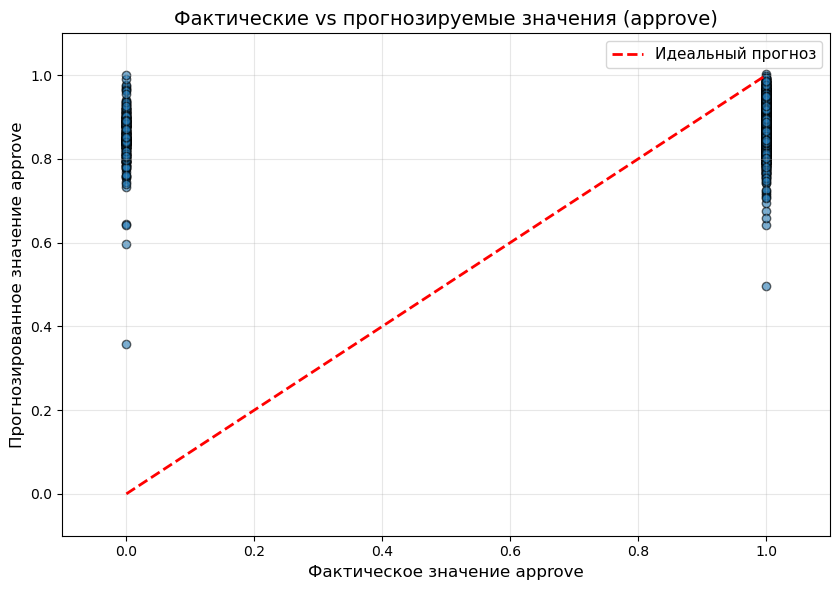

In [2125]:
#| echo: false
#| warning: false
#| output: asis

res = ols(formula = 'approve ~ 1 + appinc + I(appinc ** 2) + mortno + unem + dep + male + married + yjob + self', data=loanapp).fit()

# Прогнозы на обучающей выборке (используем fittedvalues, которые соответствуют наблюдениям модели)
fitted = res.fittedvalues
actual = res.model.endog  # фактические значения из модели

plt.figure()
plt.scatter(actual, fitted, alpha=0.6, edgecolors='black')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Идеальный прогноз')
plt.title('Фактические vs прогнозируемые значения (approve)', fontsize=14)
plt.xlabel('Фактическое значение approve', fontsize=12)
plt.ylabel('Прогнозированное значение approve', fontsize=12)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## labour force equation — график фактических и прогнозируемых значений

Для датасета `TableF5-1` рассмотрим регрессию __LFP на WA, I(WA ** 2), WE, KL6, K618, CIT, UN, np.log(FAMINC)__

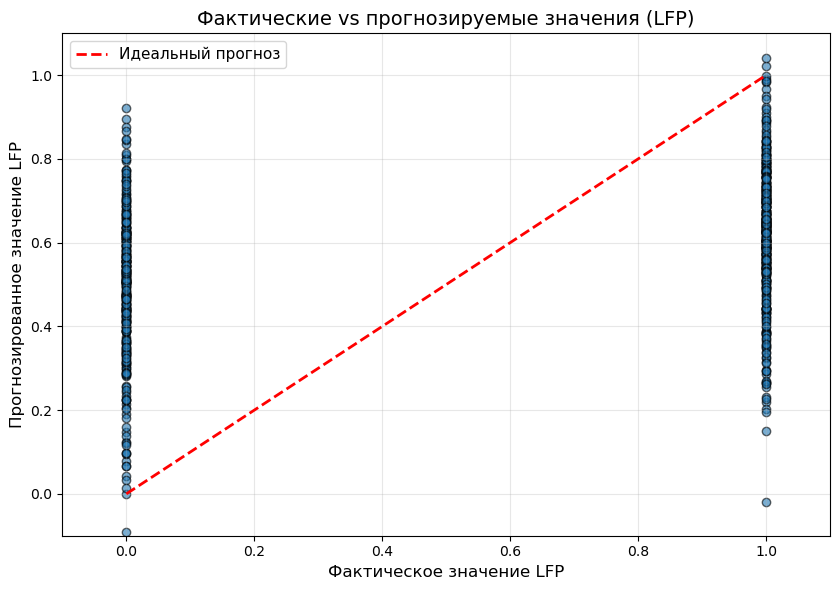

In [2126]:
#| echo: false
#| warning: false
#| output: asis

res = ols(formula = 'LFP ~ 1 + WA + I(WA ** 2) + WE + KL6 + K618 + CIT + UN + np.log(FAMINC)', data=mroz_Greene).fit()

# Прогнозы на обучающей выборке (используем fittedvalues, которые соответствуют наблюдениям модели)
fitted = res.fittedvalues
actual = res.model.endog  # фактические значения из модели

plt.figure()
plt.scatter(actual, fitted, alpha=0.6, edgecolors='black')
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Идеальный прогноз')
plt.title('Фактические vs прогнозируемые значения (LFP)', fontsize=14)
plt.xlabel('Фактическое значение LFP', fontsize=12)
plt.ylabel('Прогнозированное значение LFP', fontsize=12)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()